In [4]:
import json
with open('results/llm_debate_who.json', 'r') as f:
    debate_who= json.load(f)

print(len(debate_who))
print(type(debate_who))
print(debate_who[0]['compliance_score'])

80
<class 'list'>
2


In [5]:
comp_scores = [map['compliance_score'] for map in debate_who]

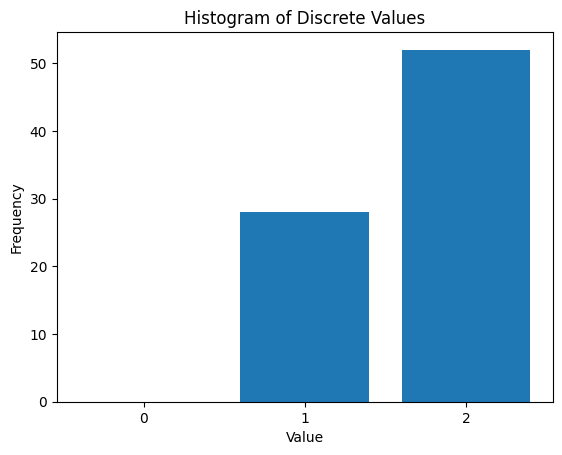

52


In [ ]:
import matplotlib.pyplot as plt



plt.hist(comp_scores, bins=[-0.5, 0.5, 1.5, 2.5], rwidth=0.8)
plt.xticks([0, 1, 2])
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Discrete Values")
plt.show()


print(comp_scores.count(2))


In [ ]:
# Pubmed experiments latency and cost report
# latency is in seconds 
#  cost is per 1000 token
{  
    'Gemini-2.5-pro':{"latency": 9.305074294687346,
    "cost": 0.0011084250585480107},
    'GPT-5 ': {
    "latency": 8.990162260359286,
    "cost": 0.0016327946916471494
    }, 
    'llm-critic-3rounds': {
        "latency": 56.65202808380127,
        "cost": 0.0058675
    }, 
    'llm-critic-2rounds': {
         "latency": 30.539761139294765,
        "cost": 0.002914583828775268
    }, 
    'llm-critic-synth': {"latency": 57.24741656780243,
    "cost": 0.005989139999999995}, 
    
}

|                         |   Latency (s) |   Cost per 1k tokens |
|:------------------------|--------------:|---------------------:|
| Gemini-2.5-pro          |          7.38 |           7.94e-06   |
| GPT-5                   |          3.5  |           7.68e-06   |
| LLM-Critic (3 rounds)   |         46.94 |           0.00612369 |
| LLM-Debate (Role-based) |         60.94 |           0.00712369 |
| LLM-Critic-Synthesizer  |         37.25 |           0.00598914 |


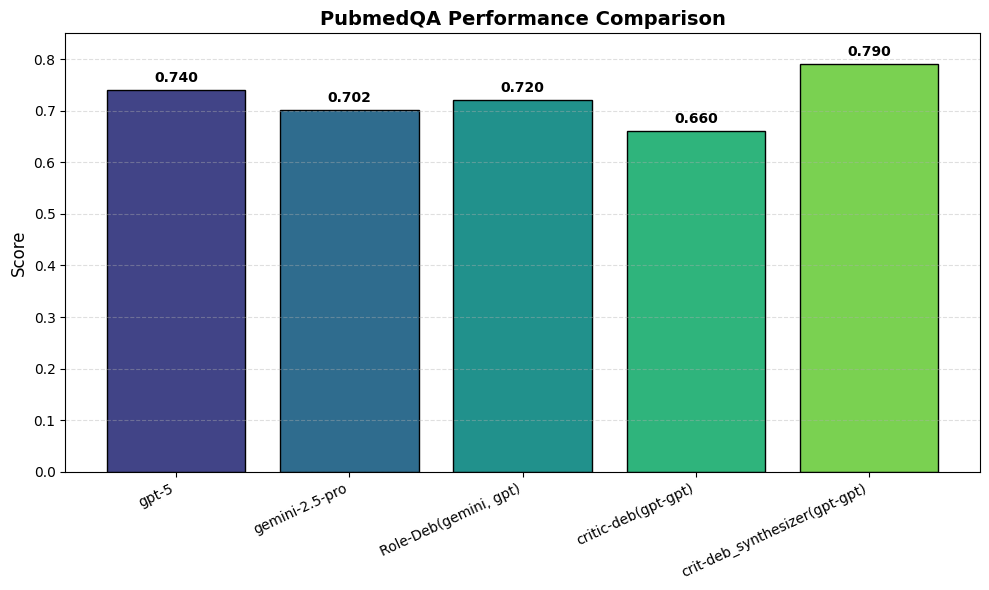

In [11]:
data={'gpt-5': 0.74, 'gemini-2.5-pro': 0.702, 
      'Role-Deb(gemini, gpt)': 0.72, 'critic-deb(gpt-gpt)': 0.66,
      'crit-deb_synthesizer': 0.79
      }
import matplotlib.pyplot as plt

# Data
data = {
    'gpt-5': 0.74,
    'gemini-2.5-pro': 0.702,
    'Role-Deb(gemini, gpt)': 0.72,
    'critic-deb(gpt-gpt)': 0.66,
    'crit-deb_synthesizer(gpt-gpt)': 0.79
}

# Extract keys and values
labels = list(data.keys())
values = list(data.values())

# Create figure
plt.figure(figsize=(10, 6))

# Use a pleasant color palette
colors = plt.cm.viridis([0.2, 0.35, 0.5, 0.65, 0.8])

bars = plt.bar(labels, values, color=colors, edgecolor='black')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Styling
plt.ylim(0, 0.85)
plt.ylabel("Score", fontsize=12)
plt.title("PubmedQA Performance Comparison", fontsize=14, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


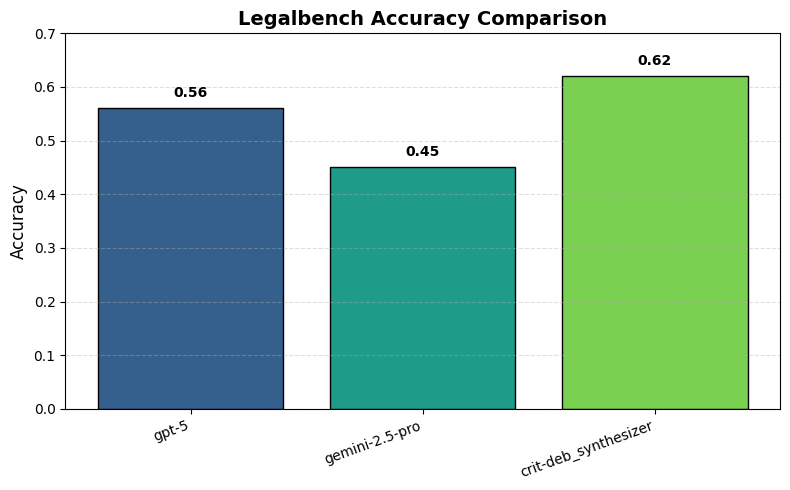

In [14]:
import matplotlib.pyplot as plt

# Data
data = {
    'gpt-5': 0.56,
    'gemini-2.5-pro': 0.45,
    'crit-deb_synthesizer': 0.62
}

# Extract keys and values
labels = list(data.keys())
values = list(data.values())

# Create figure
plt.figure(figsize=(8, 5))

# Use a pleasant color palette (same style, fewer bars)
colors = plt.cm.viridis([0.3, 0.55, 0.8])

bars = plt.bar(labels, values, color=colors, edgecolor='black')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Styling
plt.ylim(0, 0.7)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Legalbench Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
import json
with open('results/LLM_critic_subset_compliance.json', 'r') as f:
    data = json.load(f)

print(len(data))
print(data[0]['compliance_score'])

comp_scores =  [ent['compliance_score'] for ent in data ]
print(len(comp_scores))

841
2.0
841


In [21]:
import json
with open('results/LLM_critic_subset_compliance_2rounds.json', 'r') as f:
    data_comp = json.load(f)



comp_scores2 =  [ent['compliance_score'] for ent in data_comp ]
print(len(comp_scores))

841


In [23]:
import json
with open('results/gemini_results_compliance_medical.json', 'r') as f:
    data_comp3 = json.load(f)



comp_scores3 =  [ent['compliance_score'] for ent in data_comp3 ]


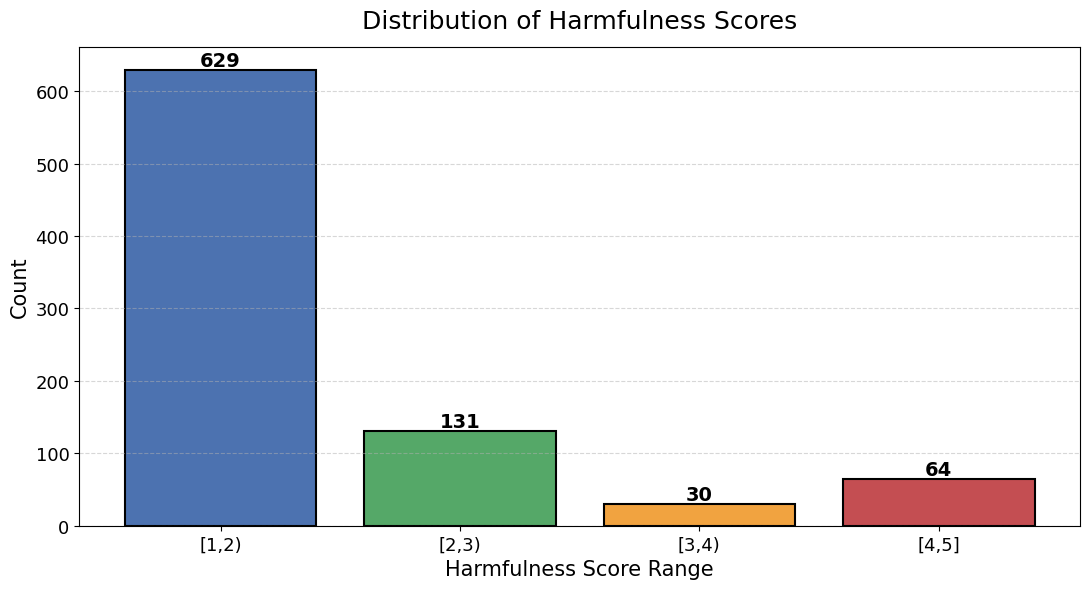

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Bin setup
bins = [1, 2, 3, 4, 5]
labels = ['[1,2)', '[2,3)', '[3,4)', '[4,5]']
colors = ['#4C72B0', '#55A868', '#F1A340', '#C44E52']

# Compute counts
counts, _ = np.histogram(comp_scores3, bins=bins)

# Plot
plt.figure(figsize=(11, 6))

bars = plt.bar(
    labels,
    counts,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

# Annotate counts on top of bars
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        str(int(count)),
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold'
    )

plt.xlabel("Harmfulness Score Range", fontsize=15)
plt.ylabel("Count", fontsize=15)
plt.title("Distribution of Harmfulness Scores", fontsize=18, pad=14)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


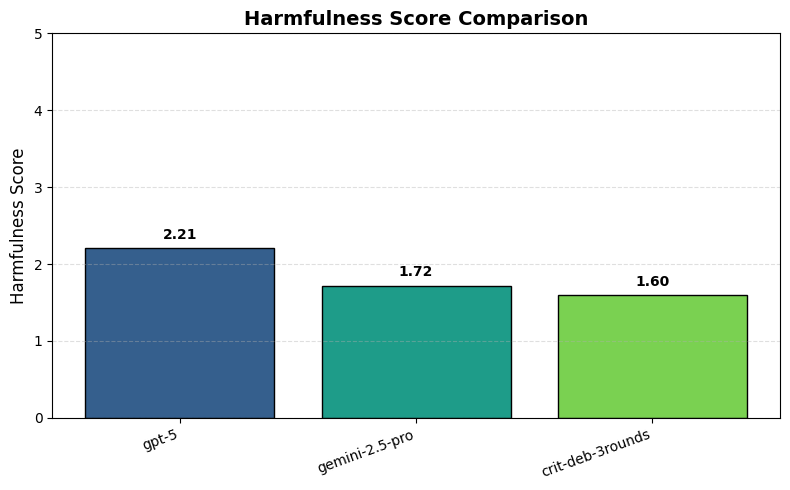

In [25]:
import matplotlib.pyplot as plt

# Example data (scores out of 5)
# data = {"GPT-4": 4.15, "GPT-3.5": 3.05, "Claude-1": 2.90}

data = {
    'gpt-5': 2.21,
    'gemini-2.5-pro': 1.72,
    'crit-deb-3rounds': 1.6, 
}

# Extract keys and values
labels = list(data.keys())
values = list(data.values())

# Create figure
plt.figure(figsize=(8, 5))

# Pleasant color palette (same style)
colors = plt.cm.viridis([0.3, 0.55, 0.8])

bars = plt.bar(labels, values, color=colors, edgecolor='black')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.08,          # adjusted for 0–5 scale
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Styling
plt.ylim(0, 5)
plt.ylabel("Harmfulness Score", fontsize=12)
plt.title("Harmfulness Score Comparison", fontsize=14, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()
